# Global and local residual intervals

Addresses R1.2–3 and R2.4. Prediction intervals are evaluated by coverage, full width and interval score together.

**Mode:** executed analysis of the committed corrected results. Expensive model refitting is available through Notebook 11 and `scripts/reproduce.py`. Replaying saved results is not presented as fresh model training.

In [1]:
from pathlib import Path
import sys, json, itertools
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.revision-repository').exists())
sys.path.insert(0, str(ROOT / 'analysis'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from notebook_support import *
from analysis import PROTEINS, TARGET, FIXED, global_quantile, local_intervals
pd.set_option('display.max_columns', 14)
pd.set_option('display.max_rows', 30)
pd.set_option('display.precision', 5)


## Recompute interval summaries from individual predictions

At nominal 90%, the interval score is `width + 20 × max(abs_error − width/2, 0)`. Global quantiles use rank ceil((n_cal+1)×0.9). Local calibration uses Gaussian weights in four training-standardized coordinates, h=0.9, and a global fallback below effective sample size 80. This is an empirical local procedure, not a conditional-coverage theorem.

In [2]:
rows=[]
for seed in range(42,47):
    p=table(f'runs/butina04_seed{seed}/test_predictions.csv')
    err=np.abs(p.y-p.prediction)
    saved=table(f'runs/butina04_seed{seed}/interval_metrics.csv').set_index('method')
    for method in ['global','joint','pheno','mie']:
        width=p['width_'+method]
        rec={'seed':seed,'method':method,'coverage':float((err<=width/2).mean()),'width':float(width.mean()),'score':float((width+20*np.maximum(err-width/2,0)).mean())}
        assert np.isclose(rec['score'],saved.loc[method,'mean_interval_score'])
        rows.append(rec)
intervals=pd.DataFrame(rows);display(intervals.groupby('method')[['coverage','width','score']].mean())

,coverage,width,score
method,,,
global,0.89872,1.60565,2.47801
joint,0.89372,1.51621,2.39742
mie,0.89593,1.55303,2.44156
pheno,0.89920,1.56856,2.42035


## Recompute the localizer for the primary partition

The fitted point predictor is kept fixed. Coordinates and residuals are joined by the saved IDs; scaling comes only from proper training.

In [3]:
seed=42;d=dataset();cfg=read_json(RESULTS/f'runs/butina04_seed{seed}/complete.json')
p=table(f'runs/butina04_seed{seed}/test_predictions.csv');cal=table(f'runs/butina04_seed{seed}/calibration_predictions.csv')
raw=np.column_stack([d[PROTEINS].mean(axis=1),d[cfg['selected_markers']].clip(0,1)])
z=pd.DataFrame((raw-np.array(cfg['coordinate_mu']))/np.array(cfg['coordinate_sd']),index=d.index)
q=global_quantile(cal.abs_residual.to_numpy())
width,neff=local_intervals(z.loc[p.ligand_id].to_numpy(),z.loc[cal.ligand_id].to_numpy(),cal.abs_residual.to_numpy(),q)
assert np.allclose(width,p.width_joint,atol=1e-10)
print('Recomputed local intervals match all',len(p),'test rows.')

Recomputed local intervals match all 2532 test rows.


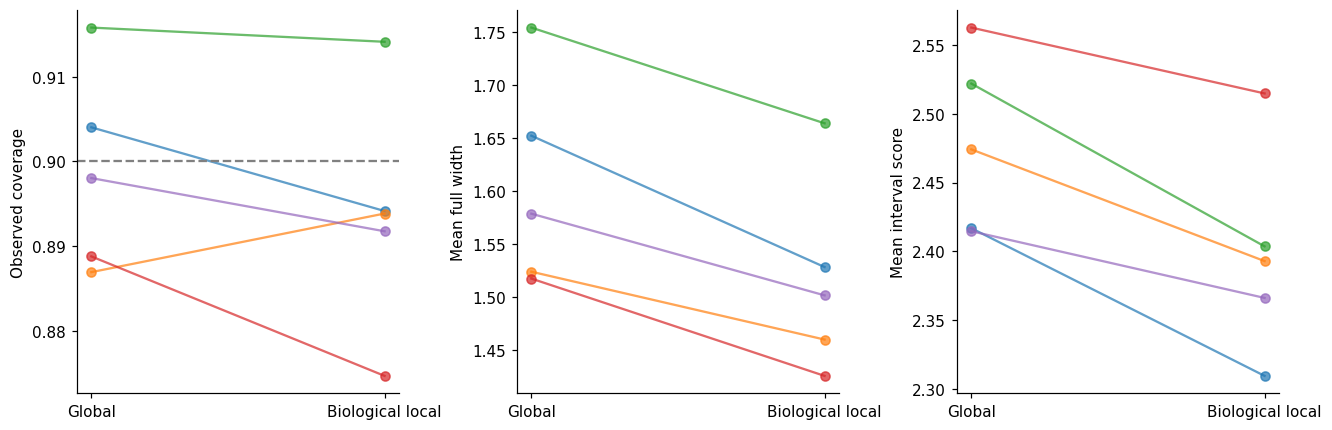

In [4]:
fig,axs=plt.subplots(1,3,figsize=(12,3.8),layout='constrained')
for ax,col,label in zip(axs,['coverage','width','score'],['Observed coverage','Mean full width','Mean interval score']):
    for seed in range(42,47):
        g=intervals[intervals.seed.eq(seed)].set_index('method').loc[['global','joint']]
        ax.plot(['Global','Biological local'],g[col],'o-',alpha=.7)
    ax.set(ylabel=label)
axs[0].axhline(.9,ls='--',color='gray');finish(fig,'global_local_intervals')

## Does localization still help the stronger ADME model?

This follow-up was initiated after the corrected ADME ranking was observed. It applies the existing localizer without choosing new settings on test outcomes. It is marked as an outcome-triggered analysis.

coverage  mean_width  mean_interval_score
model method                                           
ADME  global   0.90632     1.52475              2.33449
      joint    0.89620     1.42761              2.25713
Plain global   0.90269     1.56708              2.42028
      joint    0.89343     1.47448              2.34695

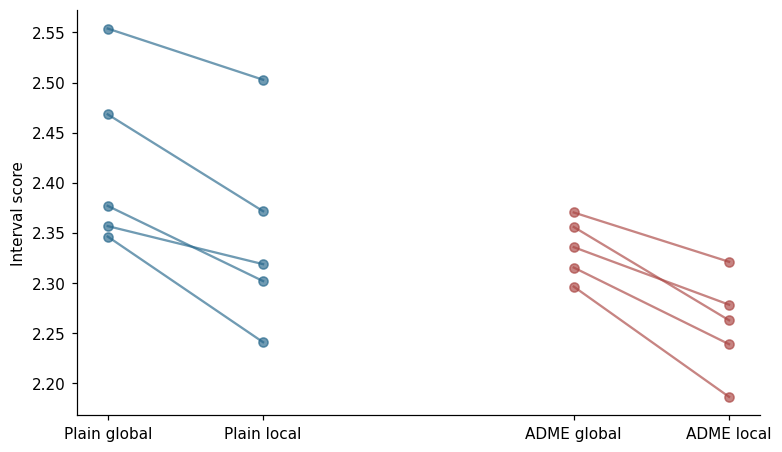

In [5]:
strong=table('strong_predictor_calibration/metrics.csv')
display(strong.groupby(['model','method'])[['coverage','mean_width','mean_interval_score']].mean())
fig,ax=plt.subplots(figsize=(7,4),layout='constrained')
for name,offset in [('Plain',0),('ADME',3)]:
    for seed in range(42,47):
        g=strong[(strong.model==name)&(strong.seed==seed)].set_index('method').loc[['global','joint']]
        ax.plot(np.array([0,1])+offset,g.mean_interval_score,'o-',color=COLORS[name],alpha=.65)
ax.set(xticks=[0,1,3,4],xticklabels=['Plain global','Plain local','ADME global','ADME local'],ylabel='Interval score');finish(fig,'stronger_predictor_localization')

## Interpretation

Intervals narrow with a modest score improvement, including with ADME. Average coverage near 90% does not establish 90% coverage in every region. Bootstrap intervals condition on the fitted model and calibration sample; they do not cover the entire training process. Source/laboratory/year stratification was not performed because those metadata were unavailable.